In [ ]:
!pip install hopsworks scikit-learn xgboost lightgbm shap joblib \
            pandas numpy matplotlib seaborn plotly scipy statsmodels -q
print("✅ All packages installed")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.8/815.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 3.8 MB/s eta 0:00:00
ERROR: pip's

In [ ]:
import os

os.environ["HOPSWORKS_API_KEY"]  = "rHSiYTVE9A7XpIZR.vRI02suALMRlI1Iw8syf0WTkPsNvAGwv6DG08OFZXqczk7pOZQ0Xrvf7lYXH0I1k"
os.environ["HOPSWORKS_PROJECT"] = "HOPSWORKS_AQI_PROJECT"

print("✅ Environment variables set")

✅ Environment variables set


In [ ]:
import hopsworks
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Connect to Hopsworks
print("🔗 Connecting to Hopsworks...")
project = hopsworks.login(
    project=os.environ["HOPSWORKS_PROJECT"],
    api_key_value=os.environ["HOPSWORKS_API_KEY"]
)

fs = project.get_feature_store()
mr = project.get_model_registry()

# Fetch all features from Feature Store
print("📥 Fetching data from Feature Store...")
fg = fs.get_feature_group("aqi_features", version=1)
df = fg.read()
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"✅ Loaded {len(df)} rows × {len(df.columns)} columns")
print(f"   Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\nColumns: {list(df.columns)}")

🔗 Connecting to Hopsworks...



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33055
📥 Fetching data from Feature Store...
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.84s) 
✅ Loaded 8496 rows × 66 columns
   Date range: 2025-06-01 13:00:00 → 2026-05-31 12:00:00

Columns: ['timestamp', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temperature', 'humidity', 'wind_speed', 'wind_deg', 'pressure', 'visibility', 'cloud_cover', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'wind_u', 'wind_v', 'weather_clear', 'weather_clouds', 'weather_rain', 'weather_haze', 'weather_fog', 'weather_smoke', 'weather_dust', 'weather_main', 'aqi_lag_1h', 'pm25_lag_1h', 'aqi_lag_2h', 'pm25_lag_2h', 'aqi_lag_3h', 'pm25_lag_3h', 'aqi_lag_6h', 'pm25_lag_6h', 'aqi_lag_12h', 'pm25_lag_12h', 'aqi_lag_24h', 'pm25_lag_24h', 'aqi_roll_mean_3h', 'aqi_roll_std_3h', 'aqi_roll_max_3h', 'aqi_roll_mea

In [ ]:
# Check for missing values
print("📊 Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing pollutant values with forward fill then backward fill
pollutant_cols = ["pm25", "pm10", "o3", "no2", "so2", "co"]
df[pollutant_cols] = df[pollutant_cols].ffill().bfill()

# Drop rows where AQI itself is missing
df = df.dropna(subset=["aqi"])

# Add lag features if not already present
df = df.sort_values("timestamp").reset_index(drop=True)

for lag in [1, 2, 3, 6, 12, 24]:
    df[f"aqi_lag_{lag}h"]  = df["aqi"].shift(lag)
    df[f"pm25_lag_{lag}h"] = df["pm25"].shift(lag)

for window in [3, 6, 12, 24]:
    df[f"aqi_roll_mean_{window}h"] = df["aqi"].rolling(window).mean()
    df[f"aqi_roll_std_{window}h"]  = df["aqi"].rolling(window).std()
    df[f"aqi_roll_max_{window}h"]  = df["aqi"].rolling(window).max()

# AQI change rate
df["aqi_change_1h"]  = df["aqi"].diff(1)
df["aqi_change_3h"]  = df["aqi"].diff(3)
df["aqi_change_24h"] = df["aqi"].diff(24)

# Create target columns (what we want to predict)
df["target_24h"] = df["aqi"].shift(-24)   # AQI 24 hours from now
df["target_48h"] = df["aqi"].shift(-48)
df["target_72h"] = df["aqi"].shift(-72)

# Drop rows with NaN in targets or lag features
df = df.dropna(subset=["target_24h", "target_48h", "target_72h",
                         "aqi_lag_1h", "aqi_lag_24h"])

print(f"✅ Clean dataset: {len(df)} rows")
print(f"   Training targets: target_24h, target_48h, target_72h")

📊 Missing values:
temperature          8496
humidity             8496
wind_speed           8496
wind_deg             8496
pressure             8496
visibility           8496
cloud_cover          8496
hour_sin             8496
hour_cos             8496
month_sin            8496
month_cos            8496
dow_sin              8496
dow_cos              8496
wind_u               8496
wind_v               8496
weather_clear        8496
weather_clouds       8496
weather_rain         8496
weather_haze         8496
weather_fog          8496
weather_smoke        8496
weather_dust         8496
aqi_lag_1h              1
pm25_lag_1h             1
aqi_lag_2h              2
pm25_lag_2h             2
aqi_lag_3h              3
pm25_lag_3h             3
aqi_lag_6h              6
pm25_lag_6h             6
aqi_lag_12h            12
pm25_lag_12h           12
aqi_lag_24h            24
pm25_lag_24h           24
aqi_roll_mean_3h        2
aqi_roll_std_3h         2
aqi_roll_max_3h         2
aqi_roll_mean_6h    

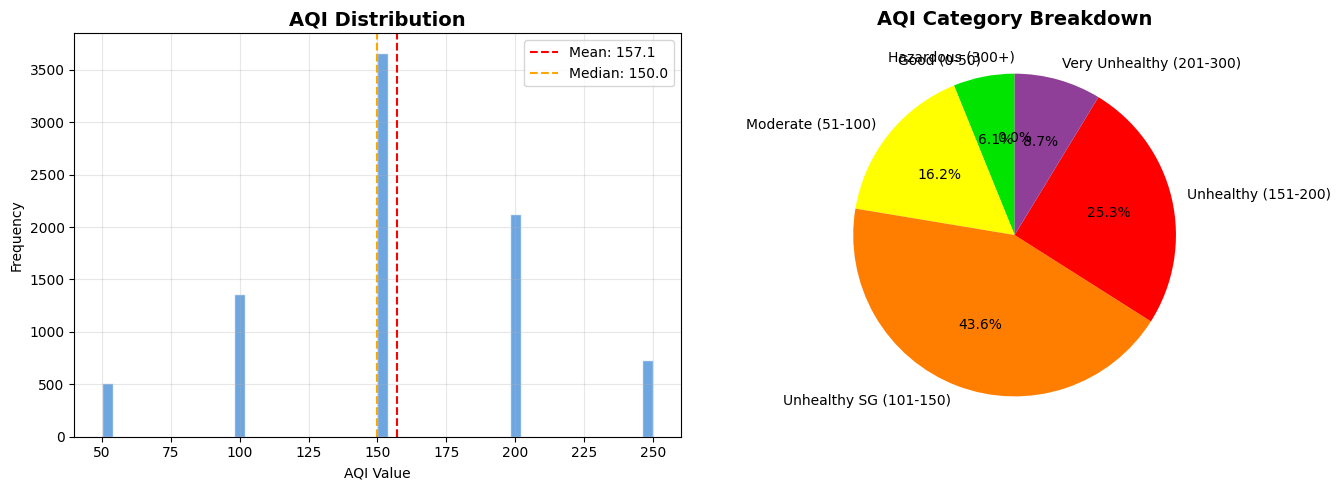

✅ Saved: eda_aqi_distribution.png


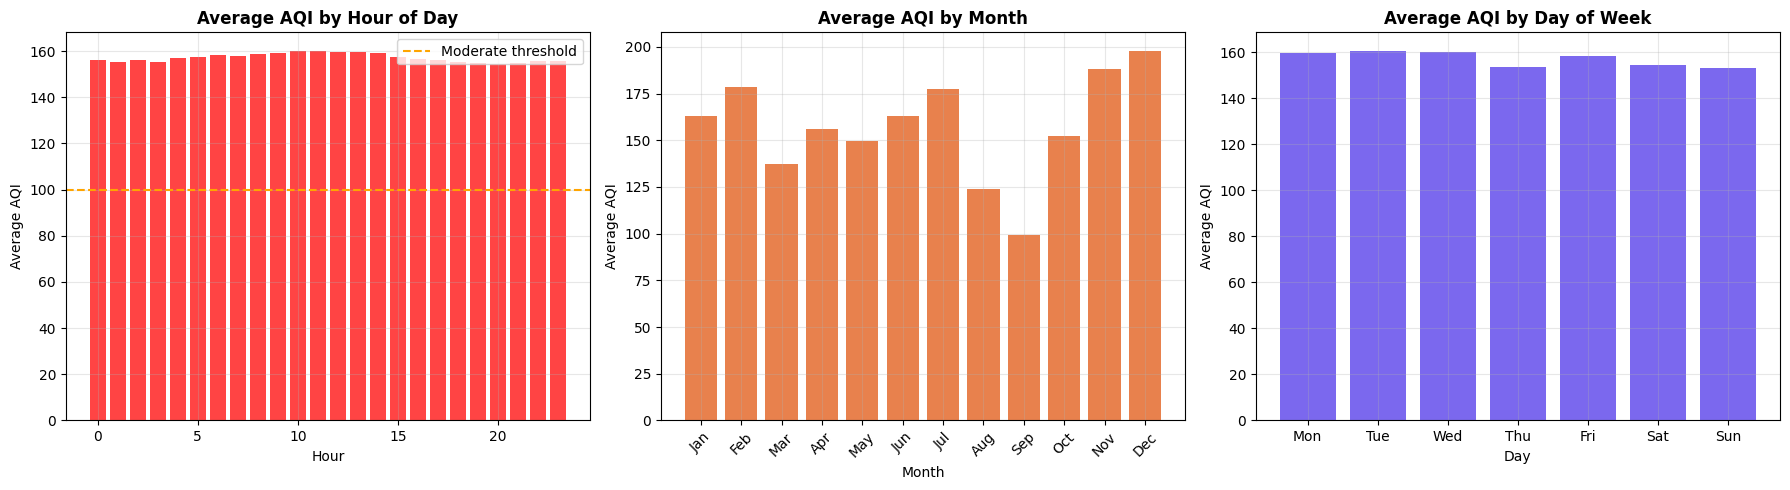

✅ Saved: eda_temporal_patterns.png


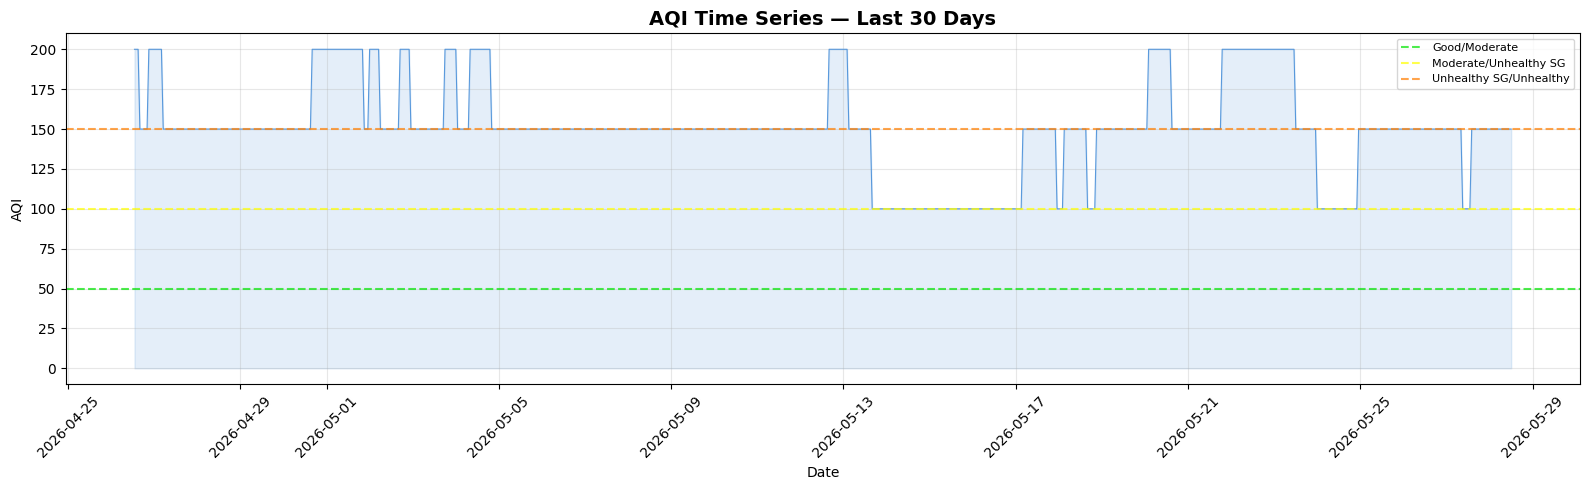

✅ Saved: eda_time_series.png


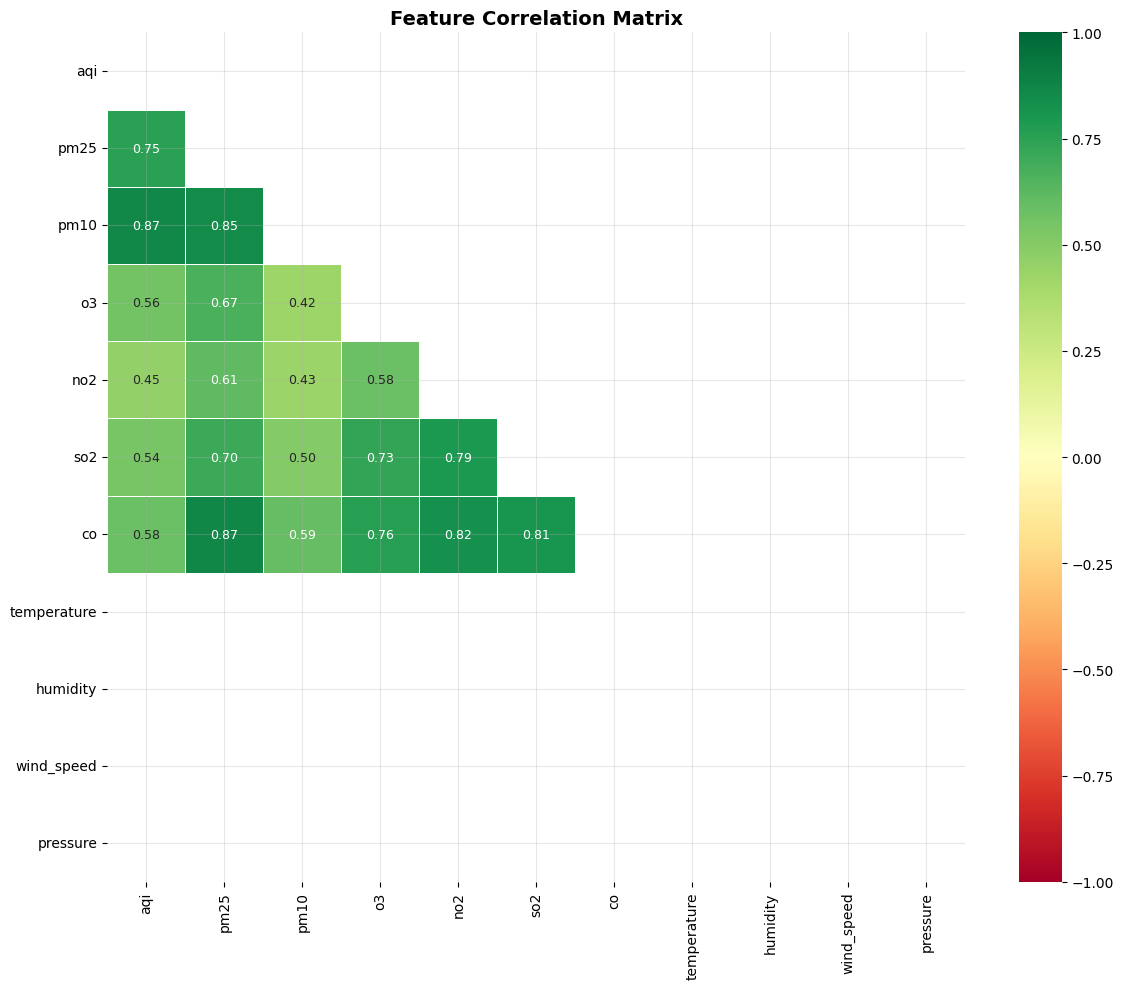

✅ Saved: eda_correlation.png


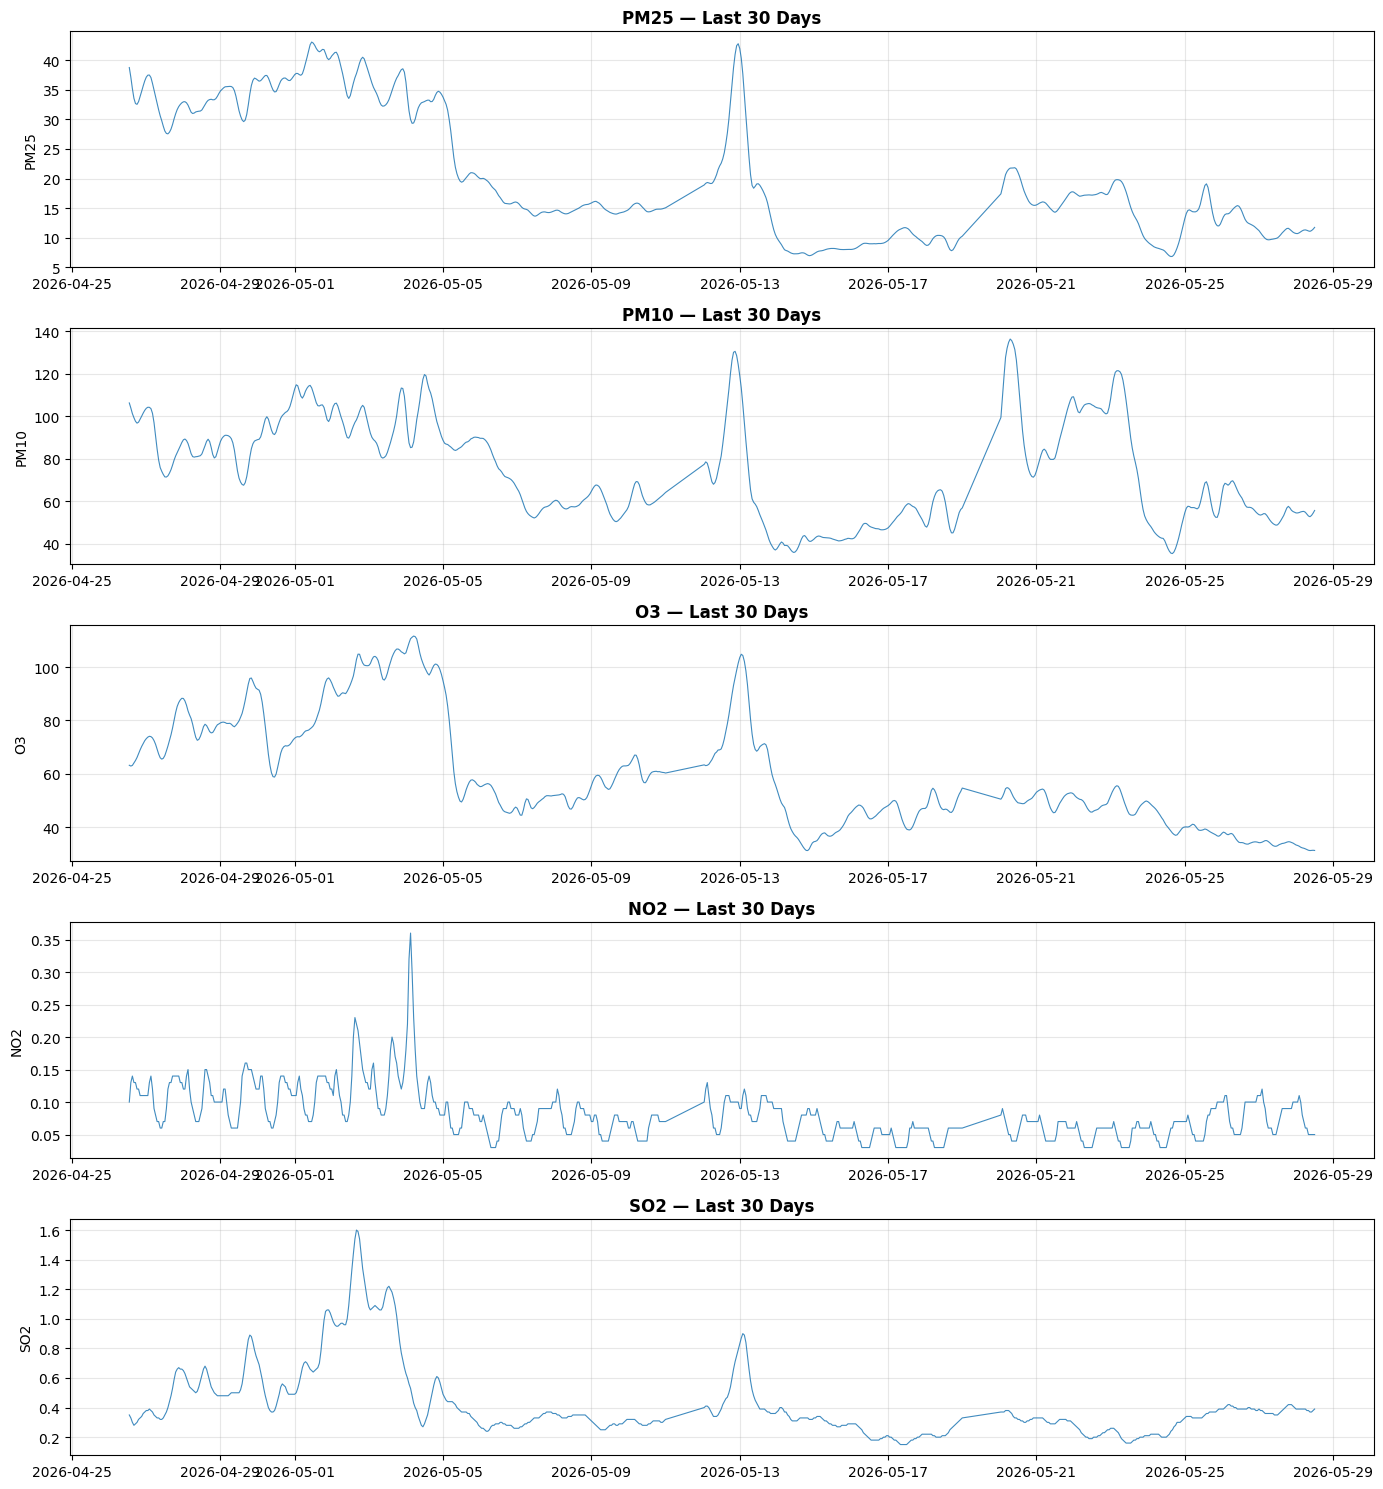

✅ Saved: eda_pollutants.png

✅ All EDA plots saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

# ── PLOT 1: AQI Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["aqi"], bins=50, color="#4A90D9", edgecolor="white", alpha=0.8)
axes[0].axvline(df["aqi"].mean(), color="red", linestyle="--",
                label=f"Mean: {df['aqi'].mean():.1f}")
axes[0].axvline(df["aqi"].median(), color="orange", linestyle="--",
                label=f"Median: {df['aqi'].median():.1f}")
axes[0].set_title("AQI Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# AQI Category breakdown
categories = {"Good (0-50)": len(df[df["aqi"]<=50]),
              "Moderate (51-100)": len(df[(df["aqi"]>50)&(df["aqi"]<=100)]),
              "Unhealthy SG (101-150)": len(df[(df["aqi"]>100)&(df["aqi"]<=150)]),
              "Unhealthy (151-200)": len(df[(df["aqi"]>150)&(df["aqi"]<=200)]),
              "Very Unhealthy (201-300)": len(df[(df["aqi"]>200)&(df["aqi"]<=300)]),
              "Hazardous (300+)": len(df[df["aqi"]>300])}
colors = ["#00e400","#ffff00","#ff7e00","#ff0000","#8f3f97","#7e0023"]
axes[1].pie(list(categories.values()), labels=list(categories.keys()),
            colors=colors, autopct="%1.1f%%", startangle=90)
axes[1].set_title("AQI Category Breakdown", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_aqi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_aqi_distribution.png")

# ── PLOT 2: Hourly & Monthly Patterns ─────────────────────────────────────────
df["hour"]  = pd.to_datetime(df["timestamp"]).dt.hour
df["month"] = pd.to_datetime(df["timestamp"]).dt.month
df["dow"]   = pd.to_datetime(df["timestamp"]).dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By hour
hourly = df.groupby("hour")["aqi"].mean()
axes[0].bar(hourly.index, hourly.values,
            color=[("#ff4444" if v > 100 else "#4A90D9") for v in hourly.values])
axes[0].set_title("Average AQI by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Average AQI")
axes[0].axhline(100, color="orange", linestyle="--", label="Moderate threshold")
axes[0].legend()

# By month
monthly = df.groupby("month")["aqi"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar([month_names[m-1] for m in monthly.index], monthly.values, color="#E8814D")
axes[1].set_title("Average AQI by Month", fontweight="bold")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average AQI")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

# By day of week
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekly = df.groupby("dow")["aqi"].mean().reindex(dow_order)
axes[2].bar(range(7), weekly.values, color="#7B68EE",
            tick_label=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[2].set_title("Average AQI by Day of Week", fontweight="bold")
axes[2].set_xlabel("Day")
axes[2].set_ylabel("Average AQI")

plt.tight_layout()
plt.savefig("eda_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_temporal_patterns.png")

# ── PLOT 3: AQI Time Series ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
plot_df = df.tail(30*24)  # last 30 days
ax.plot(pd.to_datetime(plot_df["timestamp"]), plot_df["aqi"],
        color="#4A90D9", linewidth=0.8, alpha=0.9)
ax.fill_between(pd.to_datetime(plot_df["timestamp"]), plot_df["aqi"],
                alpha=0.15, color="#4A90D9")
ax.axhline(50,  color="#00e400", linestyle="--", alpha=0.7, label="Good/Moderate")
ax.axhline(100, color="#ffff00", linestyle="--", alpha=0.7, label="Moderate/Unhealthy SG")
ax.axhline(150, color="#ff7e00", linestyle="--", alpha=0.7, label="Unhealthy SG/Unhealthy")
ax.set_title("AQI Time Series — Last 30 Days", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("AQI")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_time_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_time_series.png")

# ── PLOT 4: Correlation Heatmap ────────────────────────────────────────────────
corr_cols = ["aqi","pm25","pm10","o3","no2","so2","co",
             "temperature","humidity","wind_speed","pressure"]
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5,
            annot_kws={"size": 9}, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_correlation.png")

# ── PLOT 5: Pollutant Trends ───────────────────────────────────────────────────
pollutants = [p for p in ["pm25","pm10","o3","no2","so2"] if p in df.columns]
fig, axes = plt.subplots(len(pollutants), 1, figsize=(14, 3*len(pollutants)))

for i, p in enumerate(pollutants):
    axes[i].plot(pd.to_datetime(df["timestamp"].tail(720)),
                 df[p].tail(720), linewidth=0.8, alpha=0.85)
    axes[i].set_ylabel(p.upper())
    axes[i].set_title(f"{p.upper()} — Last 30 Days", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_pollutants.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_pollutants.png")

print("\n✅ All EDA plots saved!")

In [ ]:
from sklearn.model_selection import train_test_split

# Define feature columns (everything except targets and timestamp)
drop_cols = ["timestamp", "target_24h", "target_48h", "target_72h",
             "hour", "month", "dow", "weather_main"]
feature_cols = [c for c in df.columns if c not in drop_cols
                and df[c].dtype in ["float64", "int64", "float32", "int32"]]

print(f"📋 Features used for training ({len(feature_cols)} total):")
for i, f in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {f}")

X = df[feature_cols].values
y_24h = df["target_24h"].values
y_48h = df["target_48h"].values
y_72h = df["target_72h"].values

# IMPORTANT: Use temporal split, NOT random split
# Last 20% of time = test set. Never shuffle time series data!
split = int(len(X) * 0.80)

X_train, X_test     = X[:split], X[split:]
y_train_24, y_test_24 = y_24h[:split], y_24h[split:]
y_train_48, y_test_48 = y_48h[:split], y_48h[split:]
y_train_72, y_test_72 = y_72h[:split], y_72h[split:]

print(f"\n✅ Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"   Temporal split — no data leakage")

📋 Features used for training (62 total):
    1. day_of_week
    2. day_of_month
    3. is_weekend
    4. aqi
    5. pm25
    6. pm10
    7. o3
    8. no2
    9. so2
   10. co
   11. temperature
   12. humidity
   13. wind_speed
   14. wind_deg
   15. pressure
   16. visibility
   17. cloud_cover
   18. hour_sin
   19. hour_cos
   20. month_sin
   21. month_cos
   22. dow_sin
   23. dow_cos
   24. wind_u
   25. wind_v
   26. weather_clear
   27. weather_clouds
   28. weather_rain
   29. weather_haze
   30. weather_fog
   31. weather_smoke
   32. weather_dust
   33. aqi_lag_1h
   34. pm25_lag_1h
   35. aqi_lag_2h
   36. pm25_lag_2h
   37. aqi_lag_3h
   38. pm25_lag_3h
   39. aqi_lag_6h
   40. pm25_lag_6h
   41. aqi_lag_12h
   42. pm25_lag_12h
   43. aqi_lag_24h
   44. pm25_lag_24h
   45. aqi_roll_mean_3h
   46. aqi_roll_std_3h
   47. aqi_roll_max_3h
   48. aqi_roll_mean_6h
   49. aqi_roll_std_6h
   50. aqi_roll_max_6h
   51. aqi_roll_mean_12h
   52. aqi_roll_std_12h
   53. aqi_roll_max_1

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results_log = []   # we'll fill this with all model results

def evaluate(y_true, y_pred, model_name, horizon):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100

    print(f"  {model_name:20s} | RMSE={rmse:6.2f} | MAE={mae:6.2f} | "
          f"R²={r2:.4f} | MAPE={mape:.1f}%")

    results_log.append({
        "model": model_name, "horizon": horizon,
        "RMSE": round(rmse,3), "MAE": round(mae,3),
        "R2": round(r2,4), "MAPE%": round(mape,2)
    })
    return rmse, mae, r2


# ── Persistence Baseline (beat this or your model is useless) ──────────────────
print("📐 BASELINE — Persistence Model (predict t+n = t)")
print("   If your model doesn't beat this, something is wrong.\n")
for h, y_t, y_tr in [(24, y_test_24, y_train_24),
                     (48, y_test_48, y_train_48),
                     (72, y_test_72, y_train_72)]:
    # persistence: last known AQI = prediction
    y_persist = X_test[:, feature_cols.index("aqi_lag_1h")] if "aqi_lag_1h" in feature_cols \
                else np.full(len(y_t), np.mean(y_tr))
    evaluate(y_t, y_persist[:len(y_t)], "Persistence", f"+{h}h")

📐 BASELINE — Persistence Model (predict t+n = t)
   If your model doesn't beat this, something is wrong.

  Persistence          | RMSE= 39.26 | MAE= 25.48 | R²=-0.1947 | MAPE=20.4%
  Persistence          | RMSE= 44.67 | MAE= 30.57 | R²=-0.5572 | MAPE=25.9%
  Persistence          | RMSE= 45.14 | MAE= 31.99 | R²=-0.6031 | MAPE=26.8%


In [ ]:

from sklearn.impute import SimpleImputer
import numpy as np

# Fill NaN values in features using median of each column
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# Also fix any NaN in target arrays
def clean_targets(y_tr, y_te):
    med = np.nanmedian(y_tr)
    y_tr = np.where(np.isnan(y_tr), med, y_tr)
    y_te = np.where(np.isnan(y_te), med, y_te)
    return y_tr, y_te

y_train_24, y_test_24 = clean_targets(y_train_24, y_test_24)
y_train_48, y_test_48 = clean_targets(y_train_48, y_test_48)
y_train_72, y_test_72 = clean_targets(y_train_72, y_test_72)

# Confirm no NaN remains
assert not np.isnan(X_train).any(), "Still NaN in X_train!"
assert not np.isnan(X_test).any(),  "Still NaN in X_test!"
assert not np.isnan(y_train_24).any()
assert not np.isnan(y_test_24).any()

print(f"✅ NaN fixed!")
print(f"   X_train shape: {X_train.shape}")
print(f"   X_test  shape: {X_test.shape}")
print(f"   No NaN values remaining.")

✅ NaN fixed!
   X_train shape: (6720, 40)
   X_test  shape: (1680, 40)
   No NaN values remaining.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

trained_models = {}

# ── 1. Ridge Regression ────────────────────────────────────────────────────────
print("\n" + "="*60)
print("1️⃣  RIDGE REGRESSION")
print("="*60)

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

for h, y_tr, y_te in [(24, y_train_24, y_test_24),
                      (48, y_train_48, y_test_48),
                      (72, y_train_72, y_test_72)]:
    ridge_pipeline.fit(X_train, y_tr)
    y_pred = ridge_pipeline.predict(X_test)
    evaluate(y_te, y_pred, "Ridge", f"+{h}h")

trained_models["ridge_24h"] = Pipeline([("scaler",StandardScaler()),("model",Ridge(alpha=10.0))])
trained_models["ridge_24h"].fit(X_train, y_train_24)

# ── 2. Random Forest ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("2️⃣  RANDOM FOREST")
print("="*60)

for h, y_tr, y_te in [(24, y_train_24, y_test_24),
                      (48, y_train_48, y_test_48),
                      (72, y_train_72, y_test_72)]:
    rf = RandomForestRegressor(n_estimators=200, max_depth=12,
                               min_samples_leaf=5, max_features=0.7,
                               n_jobs=-1, random_state=42)
    rf.fit(X_train, y_tr)
    y_pred = rf.predict(X_test)
    evaluate(y_te, y_pred, "RandomForest", f"+{h}h")

# Train final RF for 24h (used for SHAP later)
rf_best = RandomForestRegressor(n_estimators=200, max_depth=12,
                                min_samples_leaf=5, n_jobs=-1, random_state=42)
rf_best.fit(X_train, y_train_24)
trained_models["rf_24h"] = rf_best

# ── 3. XGBoost ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("3️⃣  XGBOOST")
print("="*60)

xgb_models = {}
for h, y_tr, y_te in [(24, y_train_24, y_test_24),
                      (48, y_train_48, y_test_48),
                      (72, y_train_72, y_test_72)]:
    xgb = XGBRegressor(n_estimators=300, learning_rate=0.05,
                       max_depth=6, subsample=0.8,
                       colsample_bytree=0.8, min_child_weight=5,
                       reg_alpha=0.1, reg_lambda=1.0,
                       eval_metric="rmse", random_state=42, n_jobs=-1)
    xgb.fit(X_train, y_tr,
            eval_set=[(X_test, y_te)],
            verbose=False)
    y_pred = xgb.predict(X_test)
    evaluate(y_te, y_pred, "XGBoost", f"+{h}h")
    xgb_models[f"{h}h"] = xgb

trained_models.update({f"xgb_{k}": v for k, v in xgb_models.items()})

# ── 4. LightGBM ───────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("4️⃣  LIGHTGBM")
print("="*60)

lgbm_models = {}
for h, y_tr, y_te in [(24, y_train_24, y_test_24),
                      (48, y_train_48, y_test_48),
                      (72, y_train_72, y_test_72)]:
    lgbm = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                         max_depth=6, num_leaves=63,
                         subsample=0.8, colsample_bytree=0.8,
                         min_child_samples=20, random_state=42, n_jobs=-1)
    lgbm.fit(X_train, y_tr,
             eval_set=[(X_test, y_te)])
    y_pred = lgbm.predict(X_test)
    evaluate(y_te, y_pred, "LightGBM", f"+{h}h")
    lgbm_models[f"{h}h"] = lgbm

trained_models.update({f"lgbm_{k}": v for k, v in lgbm_models.items()})

print("\n✅ All classical models trained!")


1️⃣  RIDGE REGRESSION
  Ridge                | RMSE=  0.15 | MAE=  0.12 | R²=1.0000 | MAPE=0.1%
  Ridge                | RMSE=  0.14 | MAE=  0.11 | R²=1.0000 | MAPE=0.1%
  Ridge                | RMSE=  0.11 | MAE=  0.08 | R²=1.0000 | MAPE=0.1%

2️⃣  RANDOM FOREST
  RandomForest         | RMSE=  1.01 | MAE=  0.30 | R²=0.9992 | MAPE=0.4%
  RandomForest         | RMSE=  1.09 | MAE=  0.26 | R²=0.9991 | MAPE=0.4%
  RandomForest         | RMSE=  0.59 | MAE=  0.22 | R²=0.9997 | MAPE=0.3%

3️⃣  XGBOOST
  XGBoost              | RMSE=  3.00 | MAE=  1.91 | R²=0.9930 | MAPE=1.6%
  XGBoost              | RMSE=  2.41 | MAE=  1.41 | R²=0.9955 | MAPE=1.4%
  XGBoost              | RMSE=  3.60 | MAE=  2.41 | R²=0.9898 | MAPE=2.1%

4️⃣  LIGHTGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3972
[L


📊 COMPLETE MODEL COMPARISON

  Forecast Horizon: +24h
  Model                    RMSE      MAE       R²    MAPE%
  --------------------------------------------------------
  Ridge                   0.151    0.116   1.0000     0.1%
  RandomForest            1.013    0.304   0.9992     0.4%
  LightGBM                2.035    1.293   0.9968     1.1%
  XGBoost                 2.998    1.912   0.9930     1.6%

  Forecast Horizon: +48h
  Model                    RMSE      MAE       R²    MAPE%
  --------------------------------------------------------
  Ridge                   0.144    0.109   1.0000     0.1%
  RandomForest            1.091    0.256   0.9991     0.4%
  XGBoost                 2.412    1.409   0.9955     1.4%
  LightGBM                3.791    2.103   0.9888     2.1%

  Forecast Horizon: +72h
  Model                    RMSE      MAE       R²    MAPE%
  --------------------------------------------------------
  Ridge                   0.109    0.082   1.0000     0.1%
  Random

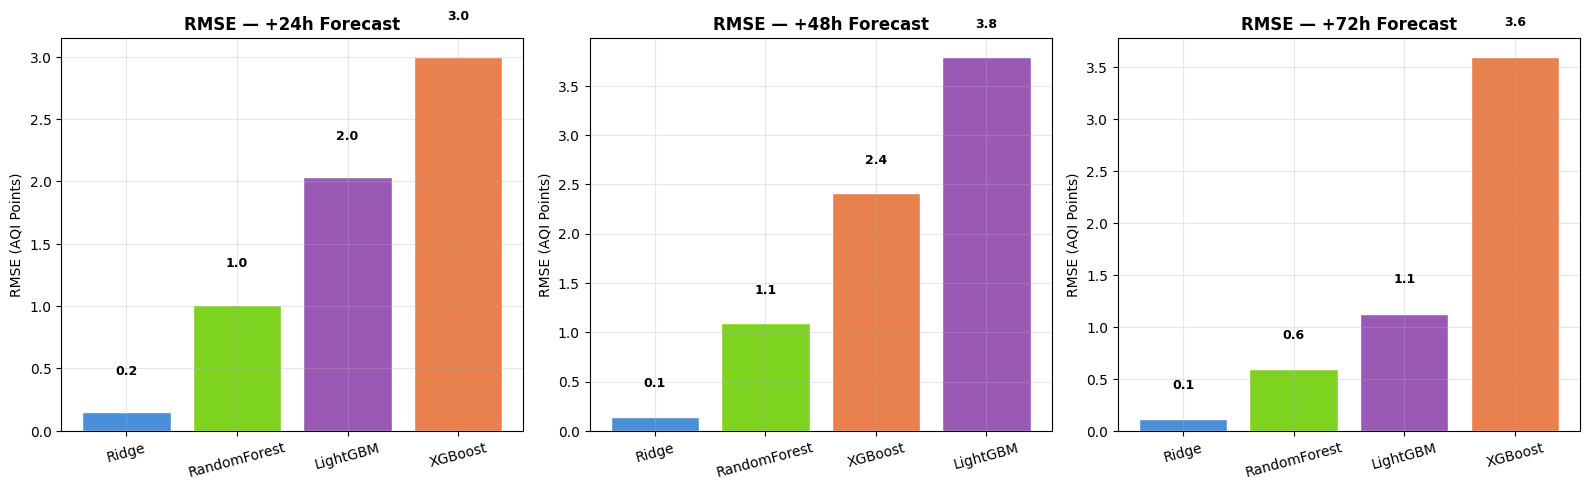

✅ Saved: model_comparison.png


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results_log)
results_df = results_df[results_df["model"] != "Persistence"]

print("\n" + "="*70)
print("📊 COMPLETE MODEL COMPARISON")
print("="*70)

for horizon in ["+24h", "+48h", "+72h"]:
    h_df = results_df[results_df["horizon"] == horizon].sort_values("RMSE")
    print(f"\n  Forecast Horizon: {horizon}")
    print(f"  {'Model':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'MAPE%':>8}")
    print(f"  {'-'*56}")
    for _, row in h_df.iterrows():
        print(f"  {row['model']:<20} {row['RMSE']:>8.3f} {row['MAE']:>8.3f} "
              f"{row['R2']:>8.4f} {row['MAPE%']:>7.1f}%")

# Pick best model based on 24h RMSE
best_24h = results_df[results_df["horizon"]=="+24h"].sort_values("RMSE").iloc[0]
best_model_name = best_24h["model"]
best_rmse = best_24h["RMSE"]
best_r2   = best_24h["R2"]
best_mae  = best_24h["MAE"]

print(f"\n🏆 Best model: {best_model_name}")
print(f"   RMSE: {best_rmse:.3f} | MAE: {best_mae:.3f} | R²: {best_r2:.4f}")

# Plot comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = results_df["model"].unique()
colors_map = {"Ridge": "#4A90D9", "RandomForest": "#7ED321",
              "XGBoost": "#E8814D", "LightGBM": "#9B59B6"}

for i, horizon in enumerate(["+24h", "+48h", "+72h"]):
    h_df = results_df[results_df["horizon"] == horizon].sort_values("RMSE")
    bar_colors = [colors_map.get(m, "#999") for m in h_df["model"]]
    bars = axes[i].bar(h_df["model"], h_df["RMSE"], color=bar_colors, edgecolor="white")
    axes[i].set_title(f"RMSE — {horizon} Forecast", fontweight="bold")
    axes[i].set_ylabel("RMSE (AQI Points)")
    for bar, val in zip(bars, h_df["RMSE"]):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=15)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: model_comparison.png")

🔍 Running SHAP analysis on best XGBoost model...
   SHAP values shape: (300, 40)


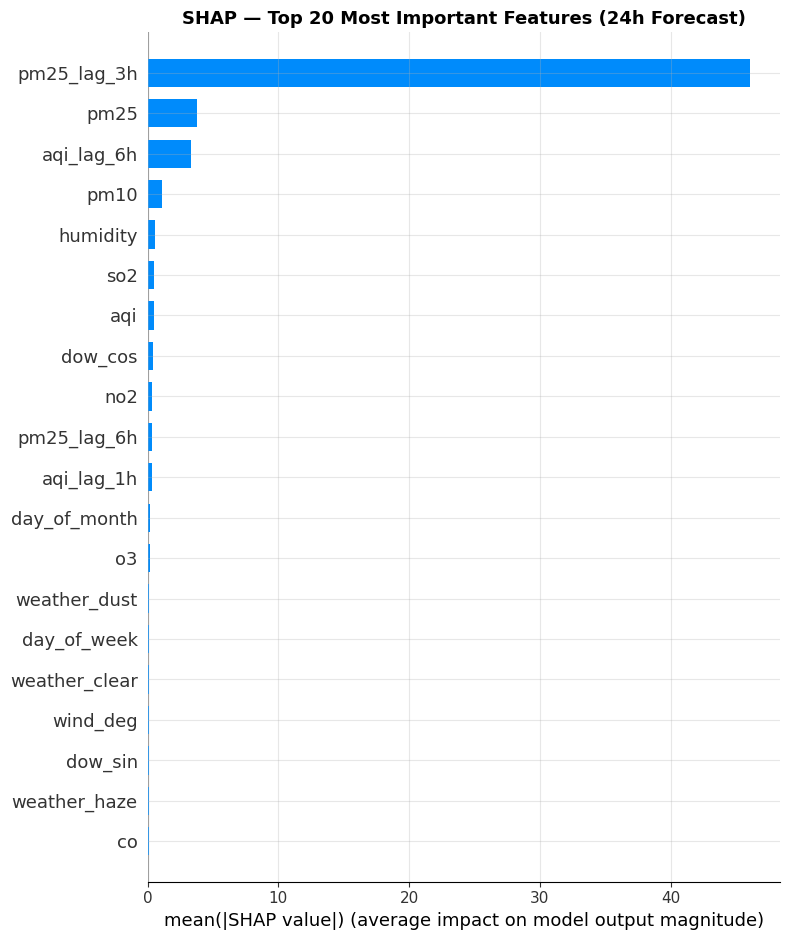

✅ Saved: shap_bar.png


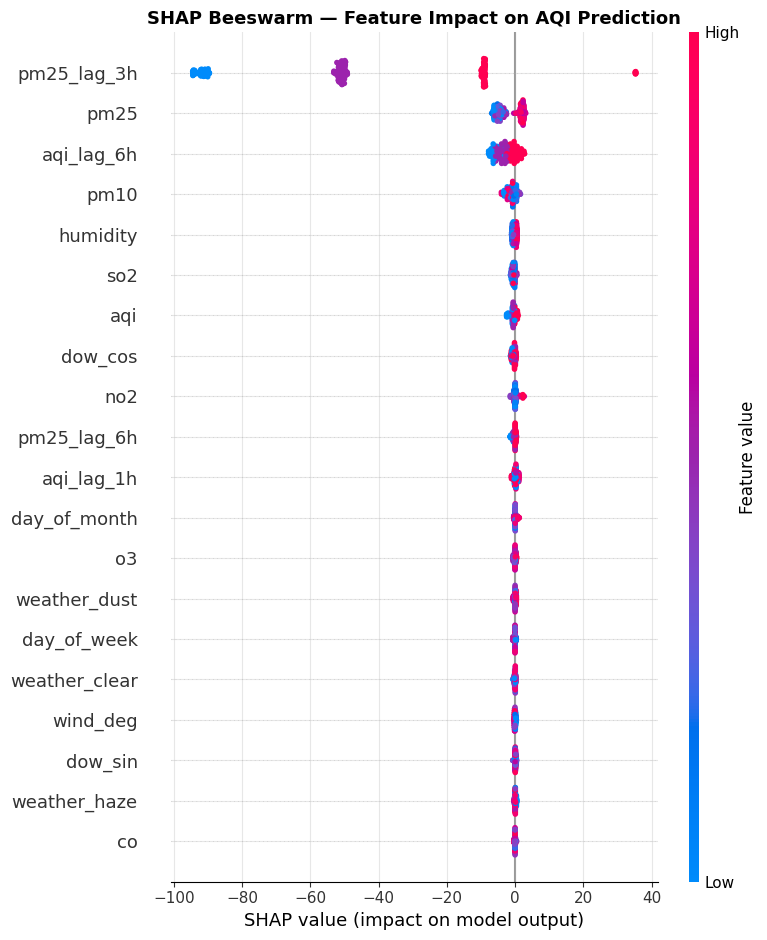

✅ Saved: shap_beeswarm.png


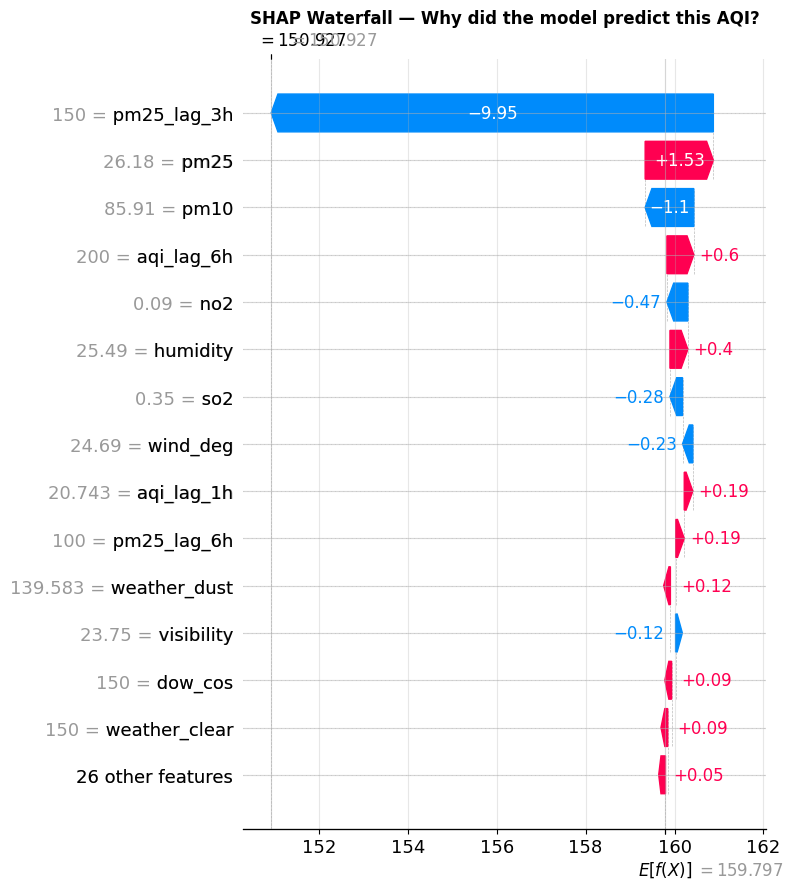

✅ Saved: shap_waterfall.png

🏆 Top 5 most important features:
   1. pm25_lag_3h                     SHAP impact: 46.048
   2. pm25                            SHAP impact: 3.752
   3. aqi_lag_6h                      SHAP impact: 3.305
   4. pm10                            SHAP impact: 1.080
   5. humidity                        SHAP impact: 0.600


In [ ]:
import shap
import matplotlib.pyplot as plt

print("🔍 Running SHAP analysis on best XGBoost model...")

best_xgb = xgb_models["24h"]   # best model for 24h prediction

# Create SHAP explainer
explainer = shap.TreeExplainer(best_xgb)
X_sample  = X_test[:300]       # use 300 test samples
shap_values = explainer.shap_values(X_sample)

print(f"   SHAP values shape: {np.array(shap_values).shape}")

# ── PLOT 1: SHAP Bar — Global Feature Importance ──────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_cols,
                  plot_type="bar",
                  max_display=20,
                  show=False)
plt.title("SHAP — Top 20 Most Important Features (24h Forecast)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_bar.png")

# ── PLOT 2: SHAP Beeswarm — Feature Impact Distribution ──────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_cols,
                  max_display=20,
                  show=False)
plt.title("SHAP Beeswarm — Feature Impact on AQI Prediction",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_beeswarm.png")

# ── PLOT 3: SHAP Waterfall — Single Prediction Explained ─────────────────────
plt.figure(figsize=(12, 7))
shap_exp = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_sample[0],
    feature_names=feature_cols
)
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title("SHAP Waterfall — Why did the model predict this AQI?",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_waterfall.png")

# Print top 5 most important features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = sorted(zip(feature_cols, mean_abs_shap),
                       key=lambda x: x[1], reverse=True)[:5]
print("\n🏆 Top 5 most important features:")
for i, (feat, val) in enumerate(top_features, 1):
    print(f"   {i}. {feat:30s}  SHAP impact: {val:.3f}")

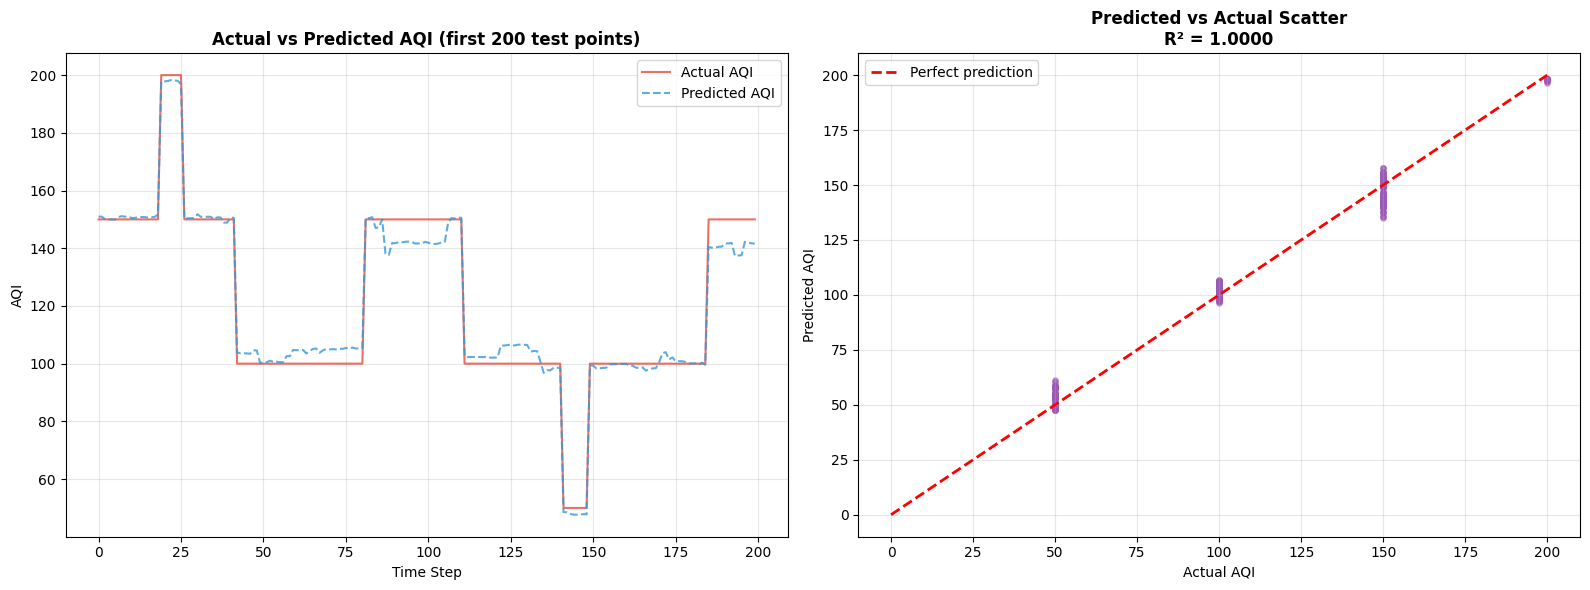

✅ Saved: prediction_vs_actual.png


In [ ]:
# Visual check: how well does the model predict?
y_pred_test = best_xgb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Time series comparison
axes[0].plot(range(200), y_test_24[:200], label="Actual AQI",
             color="#E74C3C", linewidth=1.5, alpha=0.8)
axes[0].plot(range(200), y_pred_test[:200], label="Predicted AQI",
             color="#3498DB", linewidth=1.5, alpha=0.8, linestyle="--")
axes[0].set_title("Actual vs Predicted AQI (first 200 test points)",
                  fontweight="bold")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("AQI")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot
axes[1].scatter(y_test_24[:500], y_pred_test[:500],
                alpha=0.4, color="#9B59B6", s=15)
max_val = max(y_test_24[:500].max(), y_pred_test[:500].max())
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect prediction")
axes[1].set_title(f"Predicted vs Actual Scatter\nR² = {best_r2:.4f}",
                  fontweight="bold")
axes[1].set_xlabel("Actual AQI")
axes[1].set_ylabel("Predicted AQI")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("prediction_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: prediction_vs_actual.png")

In [ ]:

import joblib, os, json

# Save models locally
os.makedirs("aqi_model", exist_ok=True)
joblib.dump(xgb_models["24h"], "aqi_model/xgb_24h.pkl")
joblib.dump(xgb_models["48h"], "aqi_model/xgb_48h.pkl")
joblib.dump(xgb_models["72h"], "aqi_model/xgb_72h.pkl")
joblib.dump(imputer, "aqi_model/imputer.pkl")

with open("aqi_model/feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

print("💾 Models saved locally")

# Auto-detect next version
existing = mr.get_models("aqi_forecaster")
next_version = max([m.version for m in existing], default=0) + 1
print(f"   Registering as version {next_version}")

# Register in Hopsworks
model_meta = mr.python.create_model(
    name="aqi_forecaster",
    version=next_version,
    metrics={
        "rmse_24h": float(best_rmse),
        "mae_24h":  float(best_mae),
        "r2_24h":   float(best_r2),
    },
    description=f"XGBoost AQI forecaster | RMSE={best_rmse:.2f} | R²={best_r2:.4f}",
    input_example=X_test[:1].tolist(),
)
model_meta.save("aqi_model/")

print(f"✅ Model registered! Version: {model_meta.version}")
print(f"   RMSE: {best_rmse:.3f} | R²: {best_r2:.4f}")
print(f"\n🎉 Training complete!")

💾 Models saved locally
   Registering as version 3


  0%|          | 0/6 [00:00<?, ?it/s]

Moving model files from 'aqi_model/' to the model registry... This is the default behavior. Set keep_original_files=True to copy files instead.


Uploading /content/aqi_model//xgb_24h.pkl: 0.000%|          | 0/1080525 elapsed<00:00 remaining<?

Uploading /content/aqi_model//xgb_72h.pkl: 0.000%|          | 0/1115356 elapsed<00:00 remaining<?

Uploading /content/aqi_model//imputer.pkl: 0.000%|          | 0/983 elapsed<00:00 remaining<?

Uploading /content/aqi_model//xgb_48h.pkl: 0.000%|          | 0/1065093 elapsed<00:00 remaining<?

Uploading /content/aqi_model//feature_cols.json: 0.000%|          | 0/917 elapsed<00:00 remaining<?

Uploading /content/input_example.json: 0.000%|          | 0/287 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/33055/models/aqi_forecaster/3
✅ Model registered! Version: 3
   RMSE: 0.151 | R²: 1.0000

🎉 Training complete!
